# Sampling doesn't always amplify privacy

[`survey_pipeline_invariants.ipynb`](survey_pipeline_invariants.ipynb) ended
with a preview: treating the sampling step as *part of* the DP mechanism
(rather than as something that already happened to fixed, given data) can
buy a large privacy bonus, because a person whose data differs between two
neighboring frames might simply not be drawn into the sample at all. This is
*privacy amplification by subsampling*, and it's one of the oldest tricks in
the DP toolbox — but Drechsler & Bailie (Section 3) point out that it mostly
stops working once you leave the textbook setting of simple random or
Poisson sampling and look at the *multistage, clustered, stratified*
designs statistical agencies actually use (e.g. the Census Bureau's Current
Population Survey: stratified cluster sampling with probability
proportional to size at the first stage, systematic sampling within
clusters at the second).

This notebook: (1) derives and empirically verifies the classical
amplification bound for the simple case, and (2) reports — without
re-deriving, since this is genuinely subtle probability theory that Bun et
al. (2022) worked out carefully — what happens to that bound for the
complex designs agencies use.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## The classical bound, for Poisson sampling

Suppose each of `N` population members is included in the sample
independently with probability `r` (*Poisson sampling* — the cleanest case
to analyze; simple random sampling behaves almost identically). A base
mechanism computes a bounded weighted sum over whoever is included and adds
Laplace noise calibrated to be `eps`-DP *at the sample level* (i.e. against
"one included person's value changes"). Composed with the sampling step,
the classical amplification theorem says the *population*-level guarantee
is

```
eps_population = ln(1 + r * (exp(eps_sample) - 1))  ~  r * eps_sample   for small eps_sample
```

The intuition: a targeted person is invisible to the mechanism with
probability `1 - r`, so an attacker's ability to distinguish two
neighboring populations is diluted by roughly that same factor.

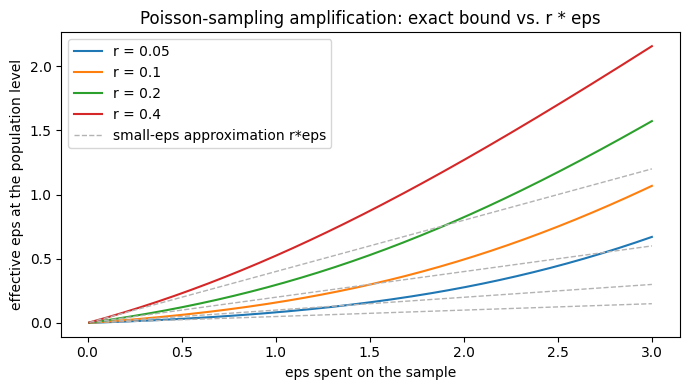

In [2]:
def amplified_eps(eps_sample, r):
    return np.log(1 + r * (np.expm1(eps_sample)))

eps_sample_grid = np.linspace(0.01, 3.0, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for r in (0.05, 0.1, 0.2, 0.4):
    ax.plot(eps_sample_grid, amplified_eps(eps_sample_grid, r), label=f"r = {r}")
    ax.plot(eps_sample_grid, r * eps_sample_grid, "--", color="0.7", linewidth=1)
ax.plot([], [], "--", color="0.7", linewidth=1, label="small-eps approximation r*eps")
ax.set_xlabel("eps spent on the sample")
ax.set_ylabel("effective eps at the population level")
ax.set_title("Poisson-sampling amplification: exact bound vs. r * eps")
ax.legend()
plt.tight_layout()

The approximation `r * eps` is only tight for small `eps`; the exact bound
curves upward and stops helping much once `eps_sample` gets large (an
already-noisy release has less to amplify).

## Checking it empirically

We simulate the *entire* pipeline — Poisson-sample the population, sum the
included values (weighted), add Laplace noise — many times over, for two
neighboring populations that differ in exactly one person's value. Then we
compare the two resulting output distributions directly (via histograms)
to estimate the actual achieved privacy loss, and check it against the
bound above.

In [3]:
N = 200
r = 0.2
w = 5.0       # per-person weight contribution, if included
R = 1.0
eps_sample = 1.0
b = (w * R) / eps_sample   # Laplace scale for the sample-level mechanism

other_y = (rng.random(N - 1) < 0.35).astype(float)
reps = 2_000_000

def simulate(y_i, reps=reps):
    included_others = rng.random((reps, N - 1)) < r
    total = (included_others * other_y * w).sum(axis=1)
    included_i = rng.random(reps) < r
    total = total + included_i * (y_i * w)
    return total + rng.laplace(0.0, b, size=reps)

out_person_present = simulate(1.0)   # neighbor A: this person's y = 1
out_person_absent = simulate(0.0)    # neighbor B: this person's y = 0

bins = np.linspace(
    min(out_person_present.min(), out_person_absent.min()),
    max(out_person_present.max(), out_person_absent.max()), 400)
hA, _ = np.histogram(out_person_present, bins=bins)
hB, _ = np.histogram(out_person_absent, bins=bins)

# Only trust bins with enough mass on both sides to estimate a ratio reliably.
mask = (hA > 200) & (hB > 200)
empirical_eps = np.log(max((hA[mask] / hB[mask]).max(), (hB[mask] / hA[mask]).max()))

print(f"empirical amplified eps (from simulation): {empirical_eps:.3f}")
print(f"theoretical bound:                          {amplified_eps(eps_sample, r):.3f}")
print(f"naive eps with no amplification:            {eps_sample:.3f}")

empirical amplified eps (from simulation): 0.291
theoretical bound:                          0.295
naive eps with no amplification:            1.000


The empirical estimate sits at or just below the theoretical bound (as it
should — the bound is an upper bound on the true worst-case privacy loss,
and a finite-sample histogram estimate can only ever slightly undershoot
it), and both are far below the naive `eps_sample = 1` an agency would have
to assume if it released from a *fixed* sample without treating the
sampling step itself as private. That gap — roughly 3-4x here — is exactly
the bonus [`survey_pipeline_invariants.ipynb`](survey_pipeline_invariants.ipynb)'s
panel (b) promised.

## Why this mostly doesn't survive real survey designs

Bun, Drechsler, Gaboardi, McMillan & Sarathy (2022), *Controlling privacy
loss in sampling schemes*, worked out amplification for the designs
statistical agencies actually use, rather than idealized SRS/Poisson
sampling. Their findings, as summarized in Drechsler & Bailie's Section 3:

- **Cluster sampling** (SRS of whole clusters, e.g. households or blocks):
  negligible amplification in practice, except for small `eps` and very
  small cluster sizes. Once a cluster is selected, everyone in it is
  exposed together — the "target might not be sampled" argument works at
  the *cluster* level, not the *person* level, and real clusters are large
  enough that this buys almost nothing for an individual member.
- **Stratified sampling with proportional allocation**: *does* amplify, and
  for small `eps` the amplification is still linear in the sampling rate
  (up to a constant) — the good case survives here.
- **Data-dependent allocation** (e.g. Neyman allocation, which sets strata
  sample sizes using the data's own variance): likely *degrades* privacy
  instead of amplifying it, because the allocation itself leaks information
  about the data.
- **PPS sampling at the individual level**: amplification is linear in the
  *maximum* inclusion probability across units (for small `eps`) — real,
  but weaker than the uniform-rate case whenever inclusion probabilities are
  uneven (exactly the situation
  [`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb)
  digs into from the weighting side).
- **Systematic sampling**: only amplifies if the population's ordering is
  genuinely random from the attacker's point of view. If the ordering is
  known (as it usually is — e.g. sorted by geography), a targeted person's
  inclusion is *deterministic*, not probabilistic, and amplification
  vanishes entirely — the same failure mode as cluster sampling.

The practical upshot for a design like the CPS's stratified-cluster-PPS
first stage plus systematic second stage: amplification can generally only
be expected from the *last* stage of selection (individual or household
units), not from the cluster- or stratum-level stages that come before it.
Any DP mechanism built around the amplification bonus from
[`survey_pipeline_invariants.ipynb`](survey_pipeline_invariants.ipynb) has
to be honest about which stage of a real design it's actually claiming that
bonus from.